## 準備

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 1.0 / (1.0 + x * x)

xi = np.array([-3 + i for i in range(7)], dtype=float)   # -3,...,3
yi = f(xi)
xs = np.linspace(-3, 3, 600)


## 2. 補間多項式（Newton の補間公式）

In [2]:
def divided_diff(x, y):
    # Newton の差分商係数
    n = len(x)
    c = y.astype(float).copy()
    for k in range(1, n):
        c[k:n] = (c[k:n] - c[k-1:n-1]) / (x[k:n] - x[0:n-k])
    return c

def newton_eval(c, xdata, X):
    # Horner 形式で補間多項式を評価
    n = len(c)
    p = np.full_like(X, c[n-1])
    for k in range(n-2, -1, -1):
        p = p * (X - xdata[k]) + c[k]
    return p

coef = divided_diff(xi, yi)
y_interp = newton_eval(coef, xi, xs)


## 3. 4次の多項式回帰（正規方程式 $X^\top X a = X^\top f$）

In [3]:
def vander(x, deg):
    return np.vstack([x**j for j in range(deg + 1)]).T

deg = 4
X = vander(xi, deg)
a = np.linalg.solve(X.T @ X, X.T @ yi)     # 正規方程式を LU で解く
y_reg = vander(xs, deg) @ a


## 4. 自然スプライン（$s''(x_1)=s''(x_n)=0$）

In [4]:
def natural_spline(x, y, X):
    n = len(x)
    h = np.diff(x)
    # 2階微分 M を解く三重対角系（自然境界 M0=M_{n-1}=0）
    A = np.zeros((n, n)); r = np.zeros(n)
    A[0, 0] = A[n-1, n-1] = 1.0
    for i in range(1, n-1):
        A[i, i-1] = h[i-1]
        A[i, i]   = 2 * (h[i-1] + h[i])
        A[i, i+1] = h[i]
        r[i] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])
    M = np.linalg.solve(A, r)
    idx = np.clip(np.searchsorted(x, X) - 1, 0, n-2)
    out = np.empty_like(X)
    for k, xx in enumerate(X):
        i = idx[k]; hi = h[i]
        A0 = (x[i+1]-xx)/hi; B0 = (xx-x[i])/hi
        out[k] = (A0*y[i] + B0*y[i+1]
                  + ((A0**3-A0)*M[i] + (B0**3-B0)*M[i+1]) * hi*hi/6)
    return out

y_spline = natural_spline(xi, yi, xs)


## 5. 6次ベジエ曲線

In [5]:
from math import comb

def bezier(y, X):
    # 制御点 F(i/6)=f(-3+i)=yi。 t=(x+3)/6
    n = len(y) - 1
    t = (X + 3) / 6
    out = np.zeros_like(X)
    for i in range(n + 1):
        out += y[i] * comb(n, i) * t**i * (1 - t)**(n - i)
    return out

y_bezier = bezier(yi, xs)


## 重ね描画

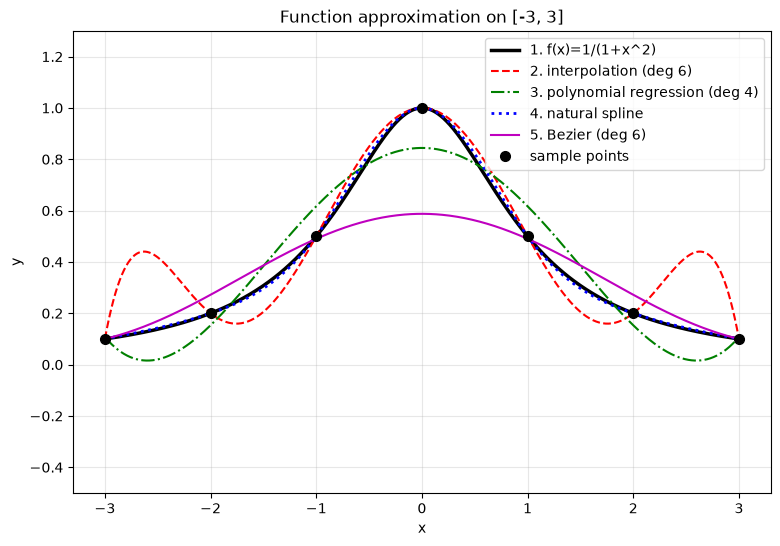

In [6]:
plt.figure(figsize=(9, 6))
plt.plot(xs, f(xs),      'k-',  lw=2.5, label='1. f(x)=1/(1+x^2)')
plt.plot(xs, y_interp,   'r--', lw=1.5, label='2. interpolation (deg 6)')
plt.plot(xs, y_reg,      'g-.', lw=1.5, label='3. polynomial regression (deg 4)')
plt.plot(xs, y_spline,   'b:',  lw=2.0, label='4. natural spline')
plt.plot(xs, y_bezier,   'm-',  lw=1.5, label='5. Bezier (deg 6)')
plt.plot(xi, yi, 'ko', ms=7, label='sample points')
plt.ylim(-0.5, 1.3)
plt.xlabel('x'); plt.ylabel('y'); plt.legend(loc='upper right')
plt.title('Function approximation on [-3, 3]'); plt.grid(alpha=0.3)
plt.show()


## 考察（条件を変えた観察）

- **補間多項式**は端付近で大きく振動する。
- **4次回帰・自然スプライン**は振動せず元の関数に近い。
- **ベジエ曲線**はサンプル点を通らず（端点以外）、全体的に滑らかだが近似は緩い。

下は点数を増やして Runge 現象を確認する例。

In [7]:
for m in [7, 11, 15]:
    xk = np.linspace(-3, 3, m)
    yk = f(xk)
    yp = newton_eval(divided_diff(xk, yk), xk, xs)
    err = np.max(np.abs(yp - f(xs)))
    print(f"補間多項式 {m:2d}点: 最大誤差 = {err:.3e}")


補間多項式  7点: 最大誤差 = 3.151e-01
補間多項式 11点: 最大誤差 = 4.998e-01
補間多項式 15点: 最大誤差 = 9.364e-01
